In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2025-04-29 09:13:52.087857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745918032.281015      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745918032.340848      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
! pip install mplfinance
! pip install pandas_ta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=6b0e2aa625d316b6b73114650f1ba25754e26c28e1f96ab17166c460bd9698f2
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [3]:
data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10


In [4]:
data['Date'] = pd.to_datetime(data['Date'])  # تبدیل ستون تاریخ به فرمت datetime
data = data[data['Date'] >= '2023-01-01']

/tmp/ipykernel_31/4204474603.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S.%f format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])  # تبدیل ستون تاریخ به فرمت datetime


In [5]:
input_features = ['Open', 'High', 'Low', 'Close']
data_values = data[input_features].values  # آرایه numpy با شکل (n_samples, 4)

# نرمال‌سازی با مقیاس مشترک
flat_data = data_values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(flat_data).reshape(data_values.shape)
scaled_inputs = scaled_data.reshape(-1, len(input_features), 1)
scaled_outputs = scaled_inputs  # اگر خروجی هم OHLC است

In [6]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 48
X, y = create_sequences(scaled_inputs, seq_length)

In [7]:
X = X.reshape(-1, seq_length, 4)
y = y.reshape(-1, 4)

train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

print("تعداد نمونه‌های Train:", len(X_train))
print("تعداد نمونه‌های Validation:", len(X_val))
print("تعداد نمونه‌های Test:", len(X_test))

تعداد نمونه‌های Train: 9818
تعداد نمونه‌های Validation: 1227
تعداد نمونه‌های Test: 1228


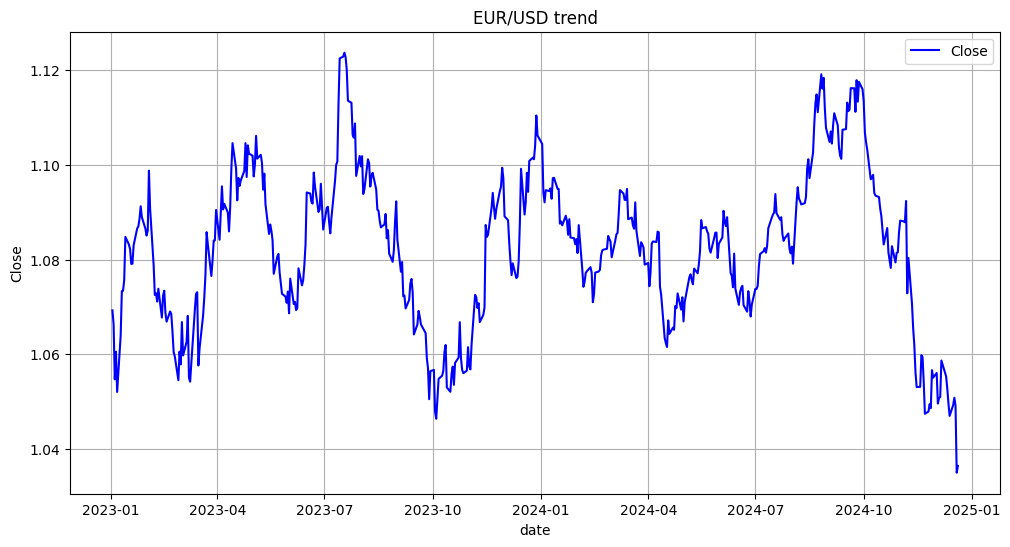

In [8]:
data['Date'] = pd.to_datetime(data['Date'], format='%d.%m.%Y %H:%M:%S.%f')
data['Day'] = data['Date'].dt.date
daily_data = data.groupby('Day').first().reset_index()  # اولین نمونه هر روز

# 4. رسم Line Plot برای Close
plt.figure(figsize=(12, 6))
plt.plot(daily_data['Date'], daily_data['Close'], label='Close', color='blue')

# 5. تنظیمات نمودار
plt.title('EUR/USD trend')
plt.xlabel('date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)

# 6. نمایش
plt.show()

In [11]:
del model

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# تابع لاس سفارشی (بدون تغییر)
def custom_ohlc_loss(y_true, y_pred, close_weight=2.0, alpha_penalty=1.0, beta_penalty=1.0, directional_weight=2.0, high_low_weight=1.5):
    open_true, high_true, low_true, close_true = tf.split(y_true, 4, axis=-1)
    open_pred, high_pred, low_pred, close_pred = tf.split(y_pred, 4, axis=-1)

    open_loss = tf.reduce_mean(tf.abs(open_true - open_pred))
    high_loss = tf.reduce_mean(tf.abs(high_true - high_pred))
    low_loss = tf.reduce_mean(tf.abs(low_true - low_pred))
    close_loss = tf.reduce_mean(tf.abs(close_true - close_pred)) * close_weight

    abs_loss = open_loss + high_loss + low_loss + close_loss

    # جریمه برای شرایط غیرمنطقی OHLC در مقادیر پیش‌بینی شده
    # low_pred باید کمتر یا مساوی open, high, close باشد
    alpha_condition = tf.reduce_mean(tf.cast(tf.logical_or(
        tf.logical_or(low_pred > open_pred, low_pred > high_pred),
        low_pred > close_pred
    ), tf.float32))
    alpha = alpha_condition * alpha_penalty

    # high_pred باید بیشتر یا مساوی open, low, close باشد
    beta_condition = tf.reduce_mean(tf.cast(tf.logical_or(
        tf.logical_or(high_pred < open_pred, high_pred < low_pred),
        high_pred < close_pred
    ), tf.float32))
    beta = beta_condition * beta_penalty

    # جریمه برای تفاوت زیاد بین دامنه واقعی و پیش‌بینی شده (High - Low)
    high_low_true_range = high_true - low_true # tf.abs unnecessary if high >= low
    high_low_pred_range = high_pred - low_pred # tf.abs unnecessary if we assume valid preds or penalize invalid ones
    high_low_diff = tf.reduce_mean(tf.abs(high_low_true_range - high_low_pred_range)) * high_low_weight

    true_direction = tf.sign(close_true - open_true)
    pred_direction = tf.sign(close_pred - open_pred)
    # Penalize mismatch in direction.
    # tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32) gives 1.0 for mismatch, 0.0 for match
    direction_mismatch = tf.cast(tf.not_equal(true_direction, pred_direction), tf.float32)
    directional_loss = tf.reduce_mean(direction_mismatch) * directional_weight
    
    # Total loss
    total_loss = abs_loss + alpha + beta + high_low_diff + directional_loss
    
    return total_loss

# تعریف مدل با استفاده از Subclassing API
class TeacherForcingOHLCModel(Model):
    def __init__(self, seq_length, input_features, lstm_units=64, dense_units=64, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.seq_length = seq_length
        self.input_features = input_features

        # لایه‌های مشترک برای expand و tile
        self.expand_dims = Lambda(lambda x: tf.expand_dims(x, axis=1))
        self.tile_layer = Lambda(lambda x: tf.tile(x, [1, self.seq_length, 1])) # به seq_length نیاز دارد

        # لایه‌های مرحله 1: پیش‌بینی Open
        self.lstm_open = LSTM(lstm_units, return_sequences=False, activation='tanh', name='lstm_open')
        self.dense_open = Dense(dense_units, activation='tanh', name='dense_open')
        self.dropout_open = Dropout(dropout_rate, name='dropout_open')
        self.open_pred_layer = Dense(1, name='open_pred')

        # لایه‌های مرحله 2: پیش‌بینی High
        self.concat_high = Concatenate(axis=-1, name='combine_high_input')
        self.lstm_high = LSTM(lstm_units, return_sequences=False, activation='tanh', name='lstm_high')
        self.dense_high = Dense(dense_units, activation='tanh', name='dense_high')
        self.dropout_high = Dropout(dropout_rate, name='dropout_high')
        self.high_pred_layer = Dense(1, name='high_pred')

        # لایه‌های مرحله 3: پیش‌بینی Low
        self.concat_low = Concatenate(axis=-1, name='combine_low_input')
        self.lstm_low = LSTM(lstm_units, return_sequences=False, activation='tanh', name='lstm_low')
        self.dense_low = Dense(dense_units, activation='tanh', name='dense_low')
        self.dropout_low = Dropout(dropout_rate, name='dropout_low')
        self.low_pred_layer = Dense(1, name='low_pred')

        # لایه‌های مرحله 4: پیش‌بینی Close
        self.concat_close = Concatenate(axis=-1, name='combine_close_input')
        self.lstm_close = LSTM(lstm_units, return_sequences=False, activation='tanh', name='lstm_close')
        self.dense_close = Dense(dense_units, activation='tanh', name='dense_close')
        self.dropout_close = Dropout(dropout_rate, name='dropout_close')
        self.close_pred_layer = Dense(1, name='close_pred')

        # لایه نهایی برای ترکیب خروجی‌ها
        self.output_concat = Concatenate(name='ohlc_output')

    def call(self, inputs, training=False, true_targets=None):
        # ورودی اولیه
        input_sequence = inputs

        # --- مرحله 1: پیش‌بینی Open ---
        lstm_out_open = self.lstm_open(input_sequence)
        dense_out_open = self.dense_open(lstm_out_open)
        dropout_out_open = self.dropout_open(dense_out_open, training=training)
        open_pred = self.open_pred_layer(dropout_out_open)

        # --- آماده‌سازی ورودی برای مرحله 2 ---
        # در زمان آموزش و اگر true_targets داده شده باشد (teacher forcing) از open_true استفاده کن
        # در غیر این صورت (زمان پیش‌بینی یا اگر true_targets نباشد) از open_pred استفاده کن
        if training and true_targets is not None:
            open_input_stage2 = true_targets[:, 0:1] # گرفتن open_true
        else:
            open_input_stage2 = open_pred
        open_expanded = self.expand_dims(open_input_stage2)
        open_tiled = self.tile_layer(open_expanded)
        combined_high_input = self.concat_high([input_sequence, open_tiled])

        # --- مرحله 2: پیش‌بینی High ---
        lstm_out_high = self.lstm_high(combined_high_input)
        dense_out_high = self.dense_high(lstm_out_high)
        dropout_out_high = self.dropout_high(dense_out_high, training=training)
        high_pred = self.high_pred_layer(dropout_out_high)

        # --- آماده‌سازی ورودی برای مرحله 3 ---
        if training and true_targets is not None:
            high_input_stage3 = true_targets[:, 1:2] # گرفتن high_true
        else:
            high_input_stage3 = high_pred
        high_expanded = self.expand_dims(high_input_stage3)
        high_tiled = self.tile_layer(high_expanded)
        combined_low_input = self.concat_low([input_sequence, open_tiled, high_tiled]) # از open_tiled قبلی استفاده کن

        # --- مرحله 3: پیش‌بینی Low ---
        lstm_out_low = self.lstm_low(combined_low_input)
        dense_out_low = self.dense_low(lstm_out_low)
        dropout_out_low = self.dropout_low(dense_out_low, training=training)
        low_pred = self.low_pred_layer(dropout_out_low)

        # --- آماده‌سازی ورودی برای مرحله 4 ---
        if training and true_targets is not None:
            low_input_stage4 = true_targets[:, 2:3] # گرفتن low_true
        else:
            low_input_stage4 = low_pred
        low_expanded = self.expand_dims(low_input_stage4)
        low_tiled = self.tile_layer(low_expanded)
        # از open_tiled و high_tiled قبلی استفاده کن
        combined_close_input = self.concat_close([input_sequence, open_tiled, high_tiled, low_tiled])

        # --- مرحله 4: پیش‌بینی Close ---
        lstm_out_close = self.lstm_close(combined_close_input)
        dense_out_close = self.dense_close(lstm_out_close)
        dropout_out_close = self.dropout_close(dense_out_close, training=training)
        close_pred = self.close_pred_layer(dropout_out_close)

        # --- ترکیب خروجی‌ها ---
        outputs = self.output_concat([open_pred, high_pred, low_pred, close_pred])
        return outputs

    def train_step(self, data):
        # Unpack data. Its structure depends on your data provider.
        # Assuming data = (x, y) where x is inputs and y is true targets.
        x, y_true = data

        with tf.GradientTape() as tape:
            # Pass true targets to the call method for teacher forcing
            y_pred = self(x, training=True, true_targets=y_true)
            # Compute the loss value
            loss = self.compiled_loss(y_true, y_pred, regularization_losses=self.losses)

        # Compute gradients
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Update weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update metrics (includes the metric that tracks the loss)
        self.compiled_metrics.update_state(y_true, y_pred)

        # Return a dict mapping metric names to current value
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        # Standard test step, uses the 'call' method without true_targets
        x, y_true = data
        y_pred = self(x, training=False) # Inference mode, no teacher forcing
        # Updates the metrics tracking the loss
        self.compiled_loss(y_true, y_pred, regularization_losses=self.losses)
        # Update the metrics.
        self.compiled_metrics.update_state(y_true, y_pred)
        # Return a dict mapping metric names to current value.
        # Note that it will include the loss (tracked in self.metrics).
        return {m.name: m.result() for m in self.metrics}

    def predict_step(self, data):
        # Standard predict step
        x = data
        y_pred = self(x, training=False) # Inference mode
        return y_pred

    # برای اینکه model.summary() کار کند، باید مدل را با شکل ورودی "build" کنیم
    # یا یک متد get_config پیاده‌سازی کنیم. ساده‌ترین راه build کردن است.
    def build(self, input_shape):
        super().build(input_shape) # این خط لازم است

# --- ساخت و کامپایل مدل ---

# فرض می‌کنیم seq_length=48 و input_features=4 (OHLC)
seq_length = 48
input_features = 4
# ایجاد نمونه از مدل
model = TeacherForcingOHLCModel(seq_length=seq_length, input_features=input_features)

# Build کردن مدل (اختیاری ولی برای summary لازم است)
# شکل ورودی باید شامل بچ سایز باشد (می‌تواند None باشد)
model.build(input_shape=(seq_length, input_features)) # استفاده از None برای بچ سایز

# کامپایل مدل
optimizer = Adam(learning_rate=5e-3)
# از تابع لاس سفارشی که تعریف کردیم استفاده می‌کنیم
model.compile(optimizer=optimizer, loss=custom_ohlc_loss, metrics=['mae', 'mape'])

# نمایش خلاصه مدل
model.summary()

Model: "teacher_forcing_ohlc_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_3 (Lambda)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_open (LSTM)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_open (Dense)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_open (Dropout)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ open_pred (Dense)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ combine_high_input (Concatenate)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_high (LSTM)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_high (Dense)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_high (Dropout)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ high_pred (Dense)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ combine_low_input (Concatenate)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_low (LSTM)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_low (Dense)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_low (Dropout)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ low_pred (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ combine_close_input (Concatenate)    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_close (LSTM)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_close (Dense)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_close (Dropout)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ close_pred (Dense)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
model

<TeacherForcingOHLCModel name=teacher_forcing_ohlc_model_3, built=True>

In [35]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, Lambda
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam


# def custom_ohlc_loss(y_true, y_pred, close_weight=2.0, alpha_penalty=1.0, beta_penalty=1.0, directional_weight=2.0, high_low_weight=1.5):
#     open_true, high_true, low_true, close_true = tf.split(y_true, 4, axis=-1)
#     open_pred, high_pred, low_pred, close_pred = tf.split(y_pred, 4, axis=-1)
    
#     open_loss = tf.reduce_mean(tf.abs(open_true - open_pred))
#     high_loss = tf.reduce_mean(tf.abs(high_true - high_pred))
#     low_loss = tf.reduce_mean(tf.abs(low_true - low_pred))
#     close_loss = tf.reduce_mean(tf.abs(close_true - close_pred)) * close_weight
    
#     abs_loss = open_loss + high_loss + low_loss + close_loss
    
#     alpha_condition = tf.reduce_mean(tf.cast(tf.logical_or(
#         tf.logical_or(low_pred > open_pred, low_pred > high_pred),
#         low_pred > close_pred
#     ), tf.float32))
#     alpha = alpha_condition * alpha_penalty
    
#     beta_condition = tf.reduce_mean(tf.cast(tf.logical_or(
#         tf.logical_or(high_pred < open_pred, high_pred < low_pred),
#         high_pred < close_pred
#     ), tf.float32))
#     beta = beta_condition * beta_penalty
    
#     high_low_true = tf.reduce_mean(tf.abs(high_true - low_true))
#     high_low_pred = tf.reduce_mean(tf.abs(high_pred - low_pred))
#     high_low_diff = tf.reduce_mean(tf.abs(high_low_true - high_low_pred)) * high_low_weight
    
#     close_true_diff = close_true[1:] - close_true[:-1]
#     close_pred_diff = close_pred[1:] - close_pred[:-1]
#     direction_mismatch = tf.reduce_mean(tf.cast(tf.sign(close_true_diff) != tf.sign(close_pred_diff), tf.float32))
#     directional_loss = direction_mismatch * directional_weight
    
#     total_loss = abs_loss + alpha + beta + high_low_diff + directional_loss
#     return total_loss

# # فرض می‌کنیم seq_length=48 و input_features=4 (OHLC)
# seq_length = 48
# input_features = 4

# # تعریف ورودی
# inputs = Input(shape=(seq_length, input_features), name='input_sequence')
# # مرحله 1: پیش‌بینی Open
# lstm_open = LSTM(64, return_sequences=False, activation='tanh', name='lstm_open')(inputs)
# dense_open = Dense(64, activation='tanh', name='dense_open')(lstm_open)
# dropout_open = Dropout(0.2)(dense_open)
# open_pred = Dense(1, name='open_pred')(dropout_open)

# # مرحله 2: پیش‌بینی High
# open_expanded = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_open')(open_pred)
# open_expanded = Lambda(lambda x: tf.tile(x, [1, seq_length, 1]), name='tile_open')(open_expanded)
# combined_high_input = Concatenate(axis=-1, name='combine_high_input')([inputs, open_expanded])
# lstm_high = LSTM(64, return_sequences=False, activation='tanh', name='lstm_high')(combined_high_input)
# dense_high = Dense(64, activation='tanh', name='dense_high')(lstm_high)
# dropout_high = Dropout(0.2)(dense_high)
# high_pred = Dense(1, name='high_pred')(dropout_high)

# # مرحله 3: پیش‌بینی Low
# high_expanded = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_high')(high_pred)
# high_expanded = Lambda(lambda x: tf.tile(x, [1, seq_length, 1]), name='tile_high')(high_expanded)
# combined_low_input = Concatenate(axis=-1, name='combine_low_input')([inputs, open_expanded, high_expanded])
# lstm_low = LSTM(64, return_sequences=False, activation='tanh', name='lstm_low')(combined_low_input)
# dense_low = Dense(64, activation='tanh', name='dense_low')(lstm_low)
# dropout_low = Dropout(0.2)(dense_low)
# low_pred = Dense(1, name='low_pred')(dropout_low)

# # مرحله 4: پیش‌بینی Close
# low_expanded = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_low')(low_pred)
# low_expanded = Lambda(lambda x: tf.tile(x, [1, seq_length, 1]), name='tile_low')(low_expanded)
# combined_close_input = Concatenate(axis=-1, name='combine_close_input')([inputs, open_expanded, high_expanded, low_expanded])
# lstm_close = LSTM(64, return_sequences=False, activation='tanh', name='lstm_close')(combined_close_input)
# dense_close = Dense(64, activation='tanh', name='dense_close')(lstm_close)
# dropout_close = Dropout(0.2)(dense_close)
# close_pred = Dense(1, name='close_pred')(dropout_close)

# # ترکیب خروجی‌ها
# outputs = Concatenate(name='ohlc_output')([open_pred, high_pred, low_pred, close_pred])

# # تعریف مدل
# model = Model(inputs=inputs, outputs=outputs)

# # کامپایل مدل
# optimizer = Adam(learning_rate=5e-3)
# model.compile(optimizer=optimizer, loss=custom_ohlc_loss, metrics=['mae', 'mape'])

# # نمایش خلاصه مدل
# model.summary()

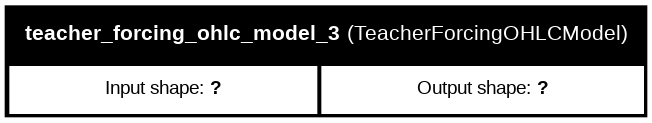

In [44]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True, dpi=96)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

import tensorflow as tf

# تعریف EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',           # معیار مانیتورینگ
    patience=10,                  # تعداد epochهایی که صبر می‌کنه
    restore_best_weights=False,   # وزن‌ها به بهترین حالت برنمی‌گردن
    start_from_epoch=40,          # از epoch دهم شروع به چک کردن می‌کنه
    verbose=1                     # گزارش رو چاپ می‌کنه
)

# تعریف ReduceLROnPlateau برای تنظیم نرخ یادگیری
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',           # معیار مانیتورینگ
    factor=0.5,                  # ضریب کاهش نرخ یادگیری
    patience=5,                   # تعداد epochهایی که صبر می‌کنه
    min_lr=1e-7,  
    start_from_epoch=5,# حداقل نرخ یادگیری
    verbose=1                     # گزارش تغییرات رو چاپ می‌کنه
)

# آموزش مدل با همه callbackها
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:592: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(
I0000 00:00:1745918148.465260     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


614/614 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - mae: 0.0552 - mape: 11.1256 - loss: 0.5013 - val_loss: 0.7352 - val_mae: 0.0263 - val_mape: 3.3947 - learning_rate: 0.0050
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - mae: 0.0210 - mape: 4.1179 - loss: 0.5096 - val_loss: 0.7770 - val_mae: 0.0208 - val_mape: 2.7664 - learning_rate: 0.0050
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - mae: 0.0150 - mape: 2.9960 - loss: 0.5144 - val_loss: 0.7600 - val_mae: 0.0110 - val_mape: 1.4578 - learning_rate: 0.0050
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - mae: 0.0117 - mape: 2.4846 - loss: 0.5104 - val_loss: 0.7579 - val_mae: 0.0092 - val_mape: 1.1845 - learning_rate: 0.0050
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - mae: 0.0113 - mape: 2.4686 - loss: 0.5129 - val_loss: 0.7525 - val_mae: 0.0123 - val_mape: 1.5945 - learning_rate: 0.0050
Epoch 6/100
613/614 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mae: 0.0111 - mape: 2.4551 - loss: 0.5134
Epoch 6: ReduceLROnPla

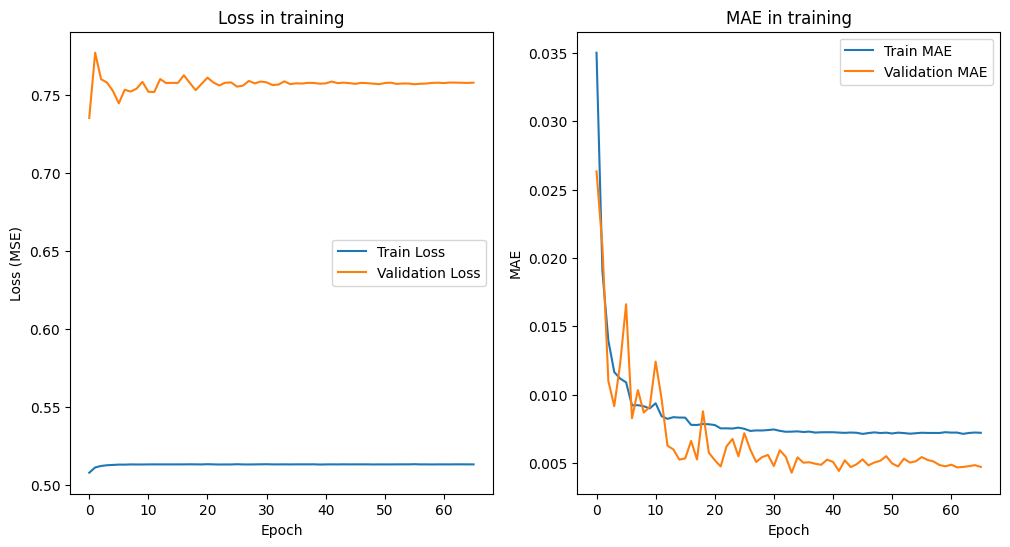

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss in training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE in training')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

معیارهای ارزیابی برای Open (داده‌های آموزشی):
MSE: 1.8361850535839146e-06
RMSE: 0.0013550590590759926
MAE: 0.0006568364875866363
R² Score: 0.9999156151206952

معیارهای ارزیابی برای High (داده‌های آموزشی):
MSE: 5.3153559202105375e-05
RMSE: 0.007290648750427178
MAE: 0.004658474169709863
R² Score: 0.9975530489293921

معیارهای ارزیابی برای Low (داده‌های آموزشی):
MSE: 5.3972256993492084e-05
RMSE: 0.007346581313338339
MAE: 0.004608385937601918
R² Score: 0.9975201258786738

معیارهای ارزیابی برای Close (داده‌های آموزشی):
MSE: 0.00010861200492528587
RMSE: 0.010421708349655822
MAE: 0.007060430912580106
R² Score: 0.9950064651095897

دقت جهت برای Close (داده‌های آموزشی): 48.11042069878781%


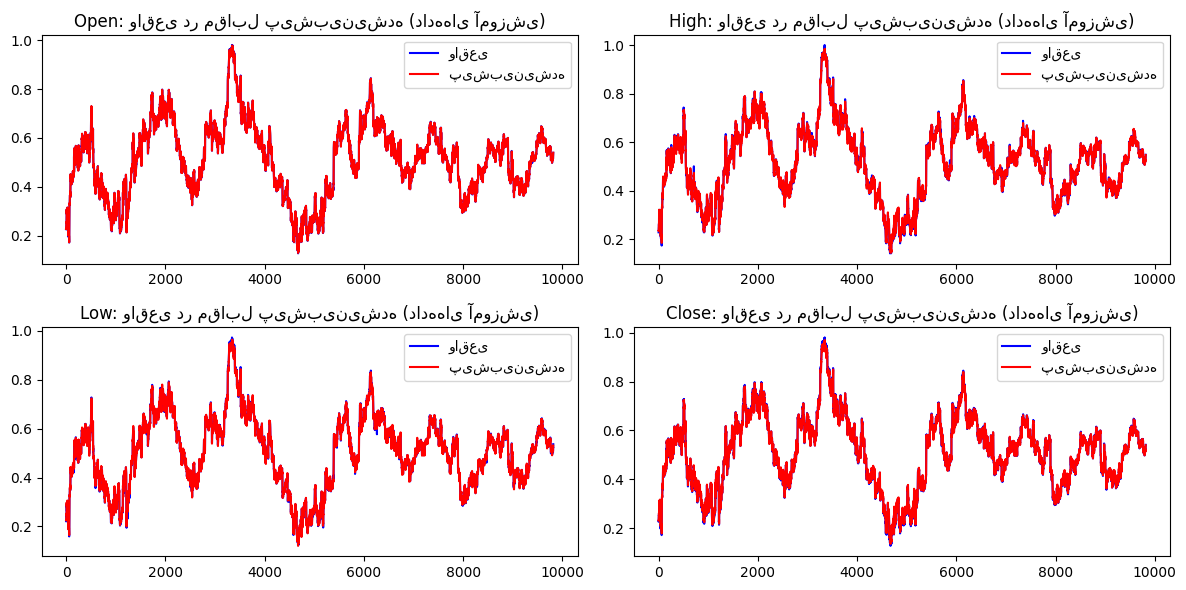

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 7. پیش‌بینی برای داده‌های آموزشی
predictions_train = model.predict(X_train)  # شکل: (n_samples, 4, 1) یا (n_samples, 4)

# 8. بررسی شکل پیش‌بینی‌ها و تنظیم آن
# اگر پیش‌بینی‌ها سه‌بعدی هستند (n_samples, 4, 1)، به دو‌بعدی (n_samples, 4) تبدیل می‌کنیم
if len(predictions_train.shape) == 3 and predictions_train.shape[2] == 1:
    predictions_train = predictions_train.reshape(predictions_train.shape[0], predictions_train.shape[1])  # (n_samples, 4)
if len(y_train.shape) == 3 and y_train.shape[2] == 1:
    y_train = y_train.reshape(y_train.shape[0], y_train.shape[1])  # (n_samples, 4)

# 9. چون نرمال‌سازی نداریم، نیازی به برگرداندن مقیاس نیست
# مستقیماً مقادیر پیش‌بینی‌شده و واقعی را استفاده می‌کنیم
predictions_open_train = predictions_train[:, 0]  # شکل: (n_samples,)
predictions_high_train = predictions_train[:, 1]
predictions_low_train = predictions_train[:, 2]
predictions_close_train = predictions_train[:, 3]

y_train_open = y_train[:, 0]
y_train_high = y_train[:, 1]
y_train_low = y_train[:, 2]
y_train_close = y_train[:, 3]

# 10. محاسبه معیارها برای هر مقدار (داده‌های آموزشی)
def calculate_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nمعیارهای ارزیابی برای {name} (داده‌های آموزشی):")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R² Score: {r2}")

calculate_metrics(y_train_open, predictions_open_train, "Open")
calculate_metrics(y_train_high, predictions_high_train, "High")
calculate_metrics(y_train_low, predictions_low_train, "Low")
calculate_metrics(y_train_close, predictions_close_train, "Close")

# 11. دقت جهت برای Close (داده‌های آموزشی)
correct_directions_train = np.sum(np.sign(predictions_close_train[1:] - predictions_close_train[:-1]) == 
                                 np.sign(y_train_close[1:] - y_train_close[:-1]))
directional_accuracy_train = correct_directions_train / (len(predictions_close_train) - 1)
print(f"\nدقت جهت برای Close (داده‌های آموزشی): {directional_accuracy_train * 100}%")

# 12. رسم پیش‌بینی‌ها (داده‌های آموزشی)
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(y_train_open, label='واقعی', color='blue')
plt.plot(predictions_open_train, label='پیش‌بینی‌شده', color='red')
plt.title('Open: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_train_high, label='واقعی', color='blue')
plt.plot(predictions_high_train, label='پیش‌بینی‌شده', color='red')
plt.title('High: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_train_low, label='واقعی', color='blue')
plt.plot(predictions_low_train, label='پیش‌بینی‌شده', color='red')
plt.title('Low: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_train_close, label='واقعی', color='blue')
plt.plot(predictions_close_train, label='پیش‌بینی‌شده', color='red')
plt.title('Close: واقعی در مقابل پیش‌بینی‌شده (داده‌های آموزشی)')
plt.legend()

plt.tight_layout()
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

معیارهای ارزیابی برای Open:
MSE: 7.373561398320202e-08
RMSE: 0.00027154302418438595
MAE: 0.0001169975775305572
R² Score: 0.9997345564250839

معیارهای ارزیابی برای High:
MSE: 5.810953123476019e-07
RMSE: 0.0007622960791894458
MAE: 0.0005566600020157018
R² Score: 0.9978761453365081

معیارهای ارزیابی برای Low:
MSE: 9.289639925695062e-07
RMSE: 0.0009638277815924929
MAE: 0.0005286647566133701
R² Score: 0.9967063724153707

معیارهای ارزیابی برای Close:
MSE: 1.6026468308469698e-06
RMSE: 0.0012659568834865467
MAE: 0.0008539401454801308
R² Score: 0.9942300326311464

دقت جهت برای Close: 47.59576202118989%


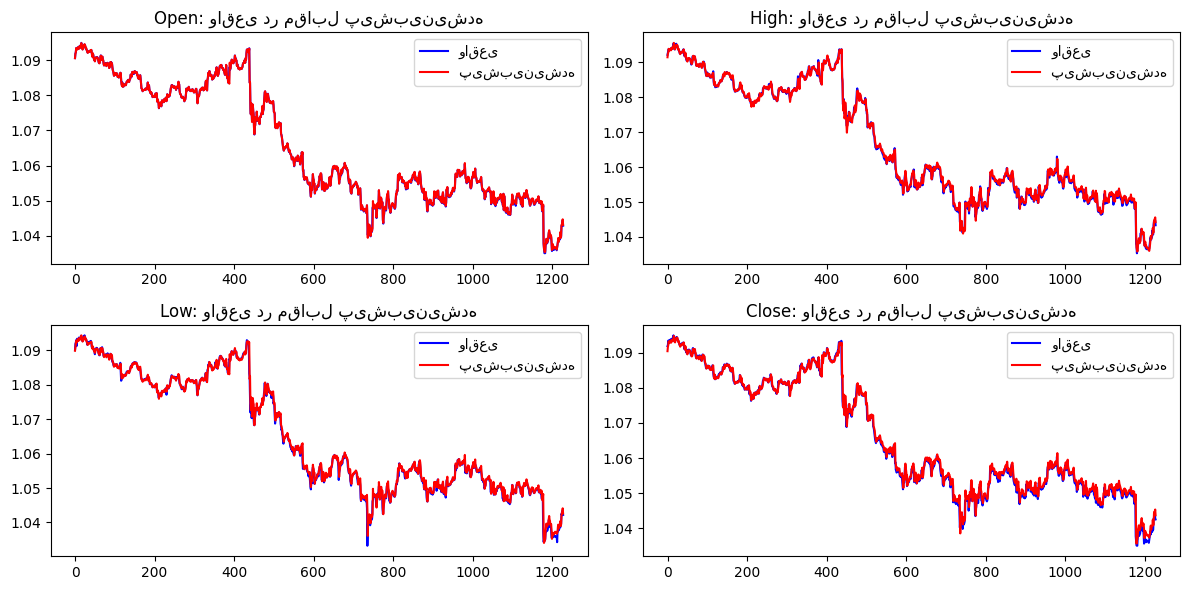

In [16]:
predictions = model.predict(X_test)  # شکل: (n_samples, 4, 1) یا (n_samples, 4)

# 7. بررسی شکل پیش‌بینی‌ها و تنظیم آن
# اگر پیش‌بینی‌ها سه‌بعدی هستند (n_samples, 4, 1)، به دو‌بعدی (n_samples, 4) تبدیل می‌کنیم
if len(predictions.shape) == 3 and predictions.shape[2] == 1:
    predictions = predictions.reshape(predictions.shape[0], predictions.shape[1])  # (n_samples, 4)
if len(y_test.shape) == 3 and y_test.shape[2] == 1:
    y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])  # (n_samples, 4)

# 8. برگرداندن به مقیاس اصلی
flat_predictions = predictions.reshape(-1, 1)  # تبدیل به آرایه تخت
flat_y_test = y_test.reshape(-1, 1)
original_predictions = scaler.inverse_transform(flat_predictions).reshape(predictions.shape)
original_y_test = scaler.inverse_transform(flat_y_test).reshape(y_test.shape)

# 9. استخراج مقادیر Open, High, Low, Close
predictions_open = original_predictions[:, 0]  # شکل: (n_samples,)
predictions_high = original_predictions[:, 1]
predictions_low = original_predictions[:, 2]
predictions_close = original_predictions[:, 3]

y_test_open = original_y_test[:, 0]
y_test_high = original_y_test[:, 1]
y_test_low = original_y_test[:, 2]
y_test_close = original_y_test[:, 3]

# 10. محاسبه معیارها برای هر مقدار
def calculate_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nمعیارهای ارزیابی برای {name}:")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R² Score: {r2}")

calculate_metrics(y_test_open, predictions_open, "Open")
calculate_metrics(y_test_high, predictions_high, "High")
calculate_metrics(y_test_low, predictions_low, "Low")
calculate_metrics(y_test_close, predictions_close, "Close")

# 11. دقت جهت برای Close
correct_directions = np.sum(np.sign(predictions_close[1:] - predictions_close[:-1]) == 
                           np.sign(y_test_close[1:] - y_test_close[:-1]))
directional_accuracy = correct_directions / (len(predictions_close) - 1)
print(f"\nدقت جهت برای Close: {directional_accuracy * 100}%")

# 12. رسم پیش‌بینی‌ها
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(y_test_open, label='واقعی', color='blue')
plt.plot(predictions_open, label='پیش‌بینی‌شده', color='red')
plt.title('Open: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_test_high, label='واقعی', color='blue')
plt.plot(predictions_high, label='پیش‌بینی‌شده', color='red')
plt.title('High: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_test_low, label='واقعی', color='blue')
plt.plot(predictions_low, label='پیش‌بینی‌شده', color='red')
plt.title('Low: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_test_close, label='واقعی', color='blue')
plt.plot(predictions_close, label='پیش‌بینی‌شده', color='red')
plt.title('Close: واقعی در مقابل پیش‌بینی‌شده')
plt.legend()

plt.tight_layout()
plt.show()

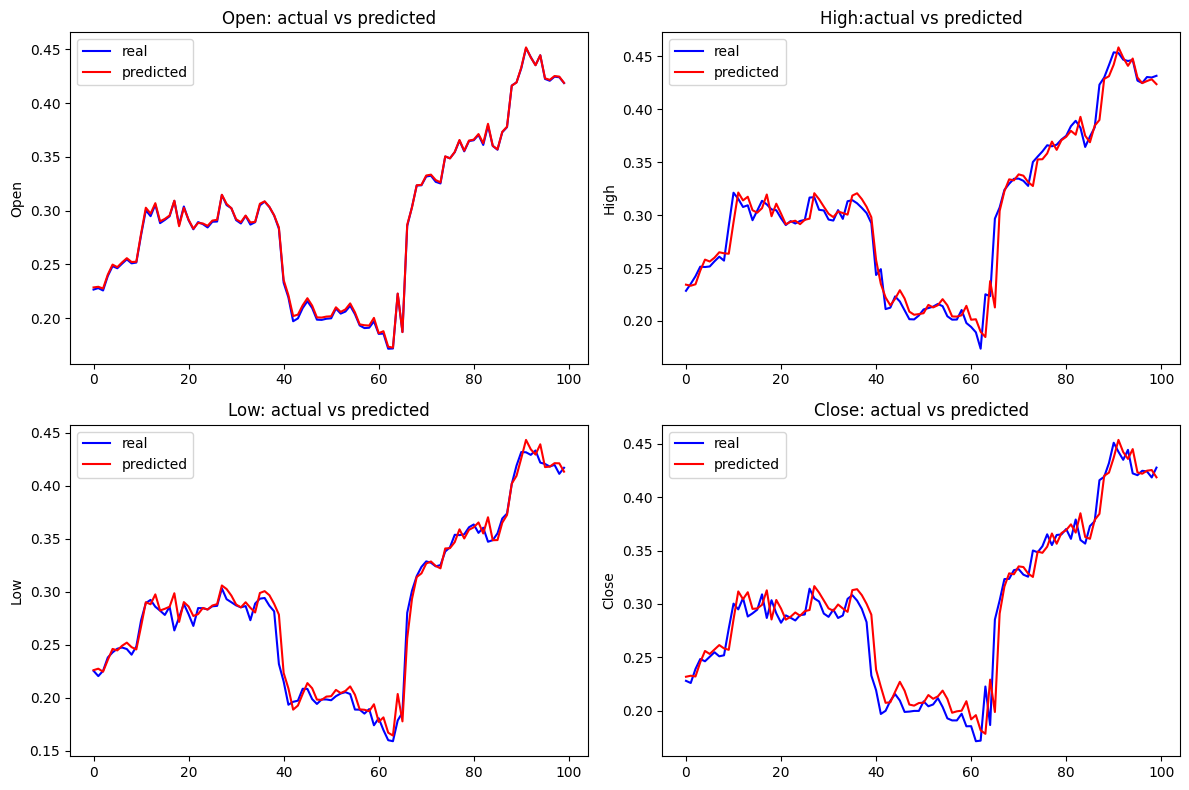

In [17]:
n_samples = 100  # تعداد نمونه‌هایی که می‌خوای نشون بدی

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(y_train_open[:n_samples], label='real', color='blue')
plt.plot(predictions_open_train[:n_samples], label='predicted', color='red')
plt.title('Open: actual vs predicted')
plt.ylabel('Open')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_train_high[:n_samples], label='real', color='blue')
plt.plot(predictions_high_train[:n_samples], label='predicted', color='red')
plt.title('High:actual vs predicted')
plt.ylabel('High')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_train_low[:n_samples], label='real', color='blue')
plt.plot(predictions_low_train[:n_samples], label='predicted', color='red')
plt.title('Low: actual vs predicted')
plt.ylabel('Low')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_train_close[:n_samples], label='real', color='blue')
plt.plot(predictions_close_train[:n_samples], label='predicted', color='red')
plt.title('Close: actual vs predicted')
plt.ylabel('Close')
plt.legend()

plt.tight_layout()
plt.show()

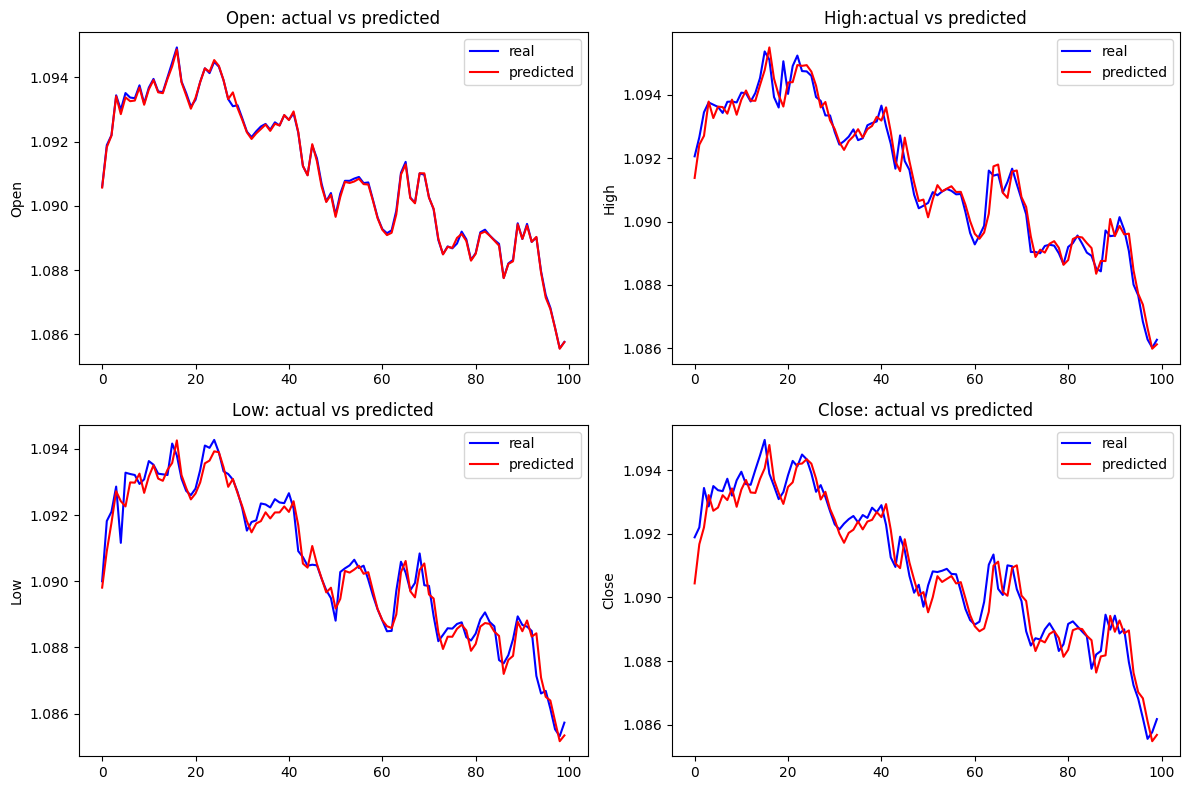

In [18]:
n_samples = 100  # تعداد نمونه‌هایی که می‌خوای نشون بدی

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(y_test_open[:n_samples], label='real', color='blue')
plt.plot(predictions_open[:n_samples], label='predicted', color='red')
plt.title('Open: actual vs predicted')
plt.ylabel('Open')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y_test_high[:n_samples], label='real', color='blue')
plt.plot(predictions_high[:n_samples], label='predicted', color='red')
plt.title('High:actual vs predicted')
plt.ylabel('High')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_test_low[:n_samples], label='real', color='blue')
plt.plot(predictions_low[:n_samples], label='predicted', color='red')
plt.title('Low: actual vs predicted')
plt.ylabel('Low')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(y_test_close[:n_samples], label='real', color='blue')
plt.plot(predictions_close[:n_samples], label='predicted', color='red')
plt.title('Close: actual vs predicted')
plt.ylabel('Close')
plt.legend()

plt.tight_layout()
plt.show()

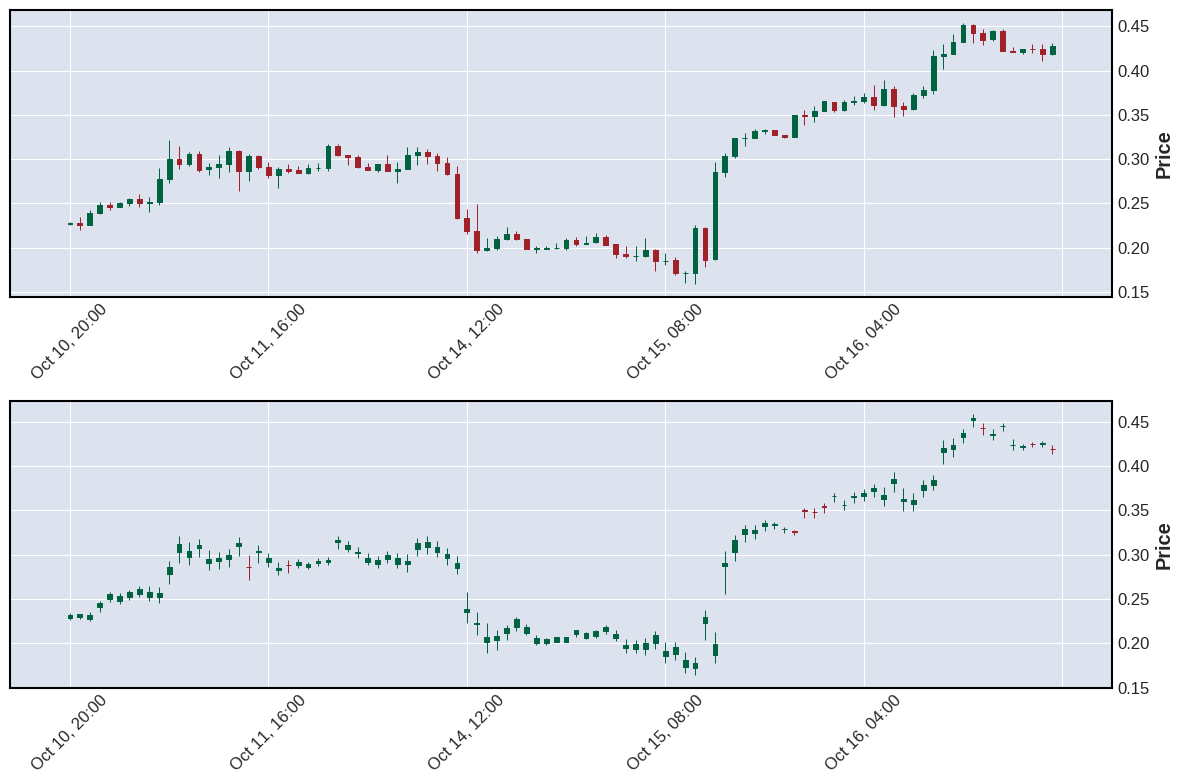

In [19]:
import mplfinance as mpf
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open_train[:n_samples].flatten(),
    'High': predictions_high_train[:n_samples].flatten(),
    'Low': predictions_low_train[:n_samples].flatten(),
    'Close': predictions_close_train[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_train_open[:n_samples].flatten(),
    'High': y_train_high[:n_samples].flatten(),
    'Low': y_train_low[:n_samples].flatten(),
    'Close': y_train_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

# رسم کندل‌ها با استفاده از mpf.make_subplots
# به جای plt.subplots، از خود mplfinance برای مدیریت زیرنمودارها استفاده می‌کنیم
fig = mpf.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

# رسم کندل‌های واقعی و پیش‌بینی‌شده
mpf.plot(actual_candles, type='candle', style='charles', ax=ax1)
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax2)

# تنظیم فاصله بین زیرنمودارها
fig.tight_layout()
mpf.show()

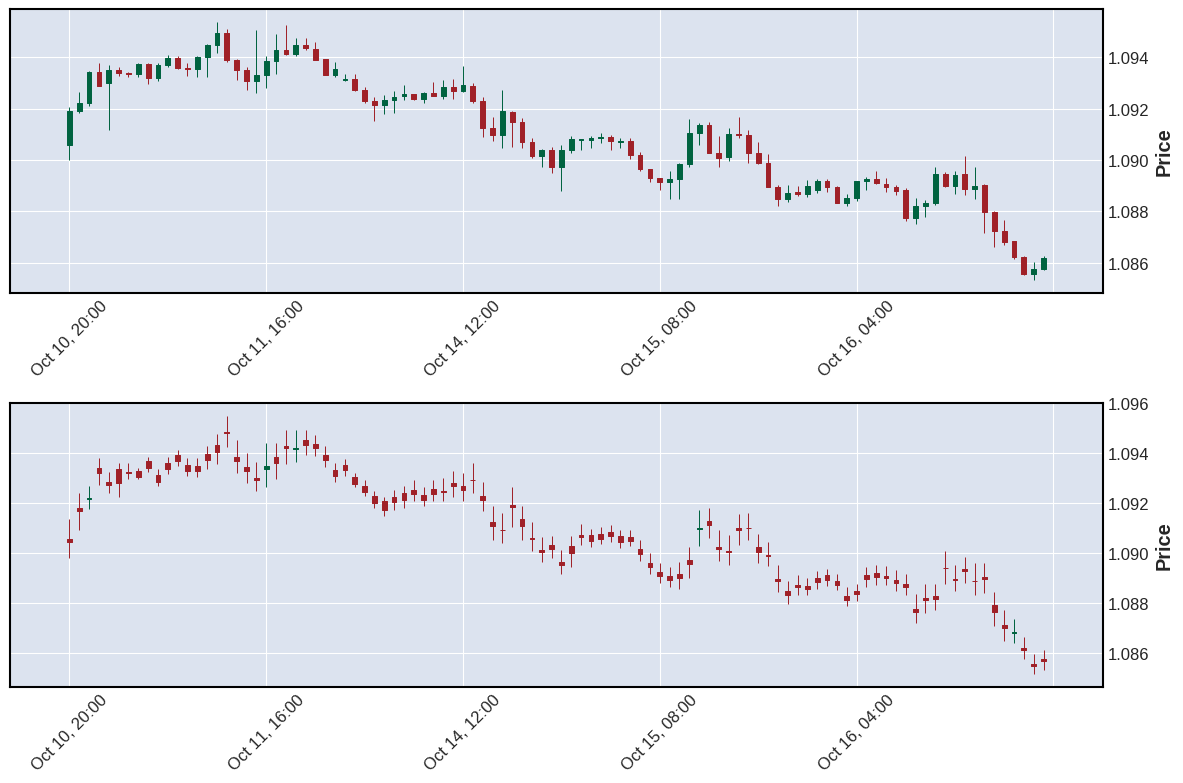

In [20]:
import mplfinance as mpf
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open[:n_samples].flatten(),
    'High': predictions_high[:n_samples].flatten(),
    'Low': predictions_low[:n_samples].flatten(),
    'Close': predictions_close[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_test_open[:n_samples].flatten(),
    'High': y_test_high[:n_samples].flatten(),
    'Low': y_test_low[:n_samples].flatten(),
    'Close': y_test_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

# رسم کندل‌ها با استفاده از mpf.make_subplots
# به جای plt.subplots، از خود mplfinance برای مدیریت زیرنمودارها استفاده می‌کنیم
fig = mpf.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

# رسم کندل‌های واقعی و پیش‌بینی‌شده
mpf.plot(actual_candles, type='candle', style='charles', ax=ax1)
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax2)

# تنظیم فاصله بین زیرنمودارها
fig.tight_layout()
mpf.show()

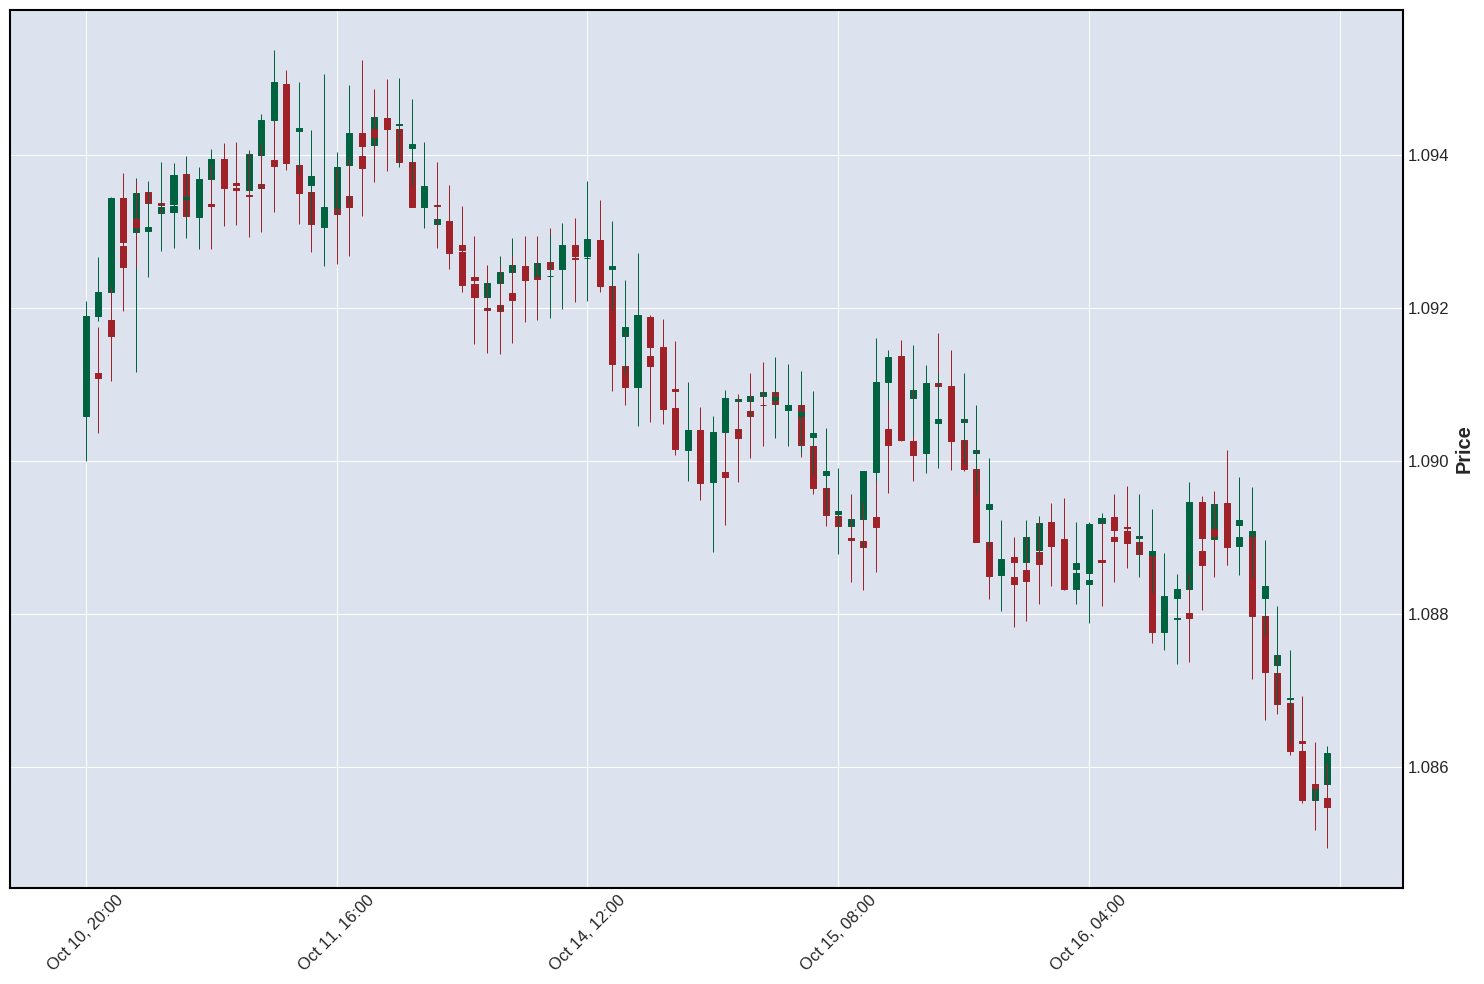

In [20]:
data['Date'] = pd.to_datetime(data['Date'], format='mixed', dayfirst=True)
dates = data['Date'].iloc[-len(predictions):].values[:n_samples]
dates = pd.to_datetime(dates)  # تبدیل به datetime

predicted_candles = pd.DataFrame({
    'Date': dates,
    'Open': predictions_open[:n_samples].flatten(),
    'High': predictions_high[:n_samples].flatten(),
    'Low': predictions_low[:n_samples].flatten(),
    'Close': predictions_close[:n_samples].flatten()
})
predicted_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
predicted_candles.index = pd.DatetimeIndex(predicted_candles.index)

actual_candles = pd.DataFrame({
    'Date': dates,
    'Open': y_test_open[:n_samples].flatten(),
    'High': y_test_high[:n_samples].flatten(),
    'Low': y_test_low[:n_samples].flatten(),
    'Close': y_test_close[:n_samples].flatten()
})
actual_candles.set_index('Date', inplace=True)
# مطمئن می‌شیم ایندکس DatetimeIndex باشه
actual_candles.index = pd.DatetimeIndex(actual_candles.index)

fig = mpf.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1)

mpf.plot(actual_candles, type='candle', style='charles', ax=ax)


# کندل‌های پیش‌بینی‌شده (پررنگ) روی همون محور
mpf.plot(predicted_candles, type='candle', style='charles', ax=ax)


# نمایش نمودار
fig.tight_layout()
mpf.show()

In [ ]:
predictions[-1]

In [ ]:
y_test[-1]